#### Central limit theorem 

Averaged 25 numbers per trial, 5,000,000 trials


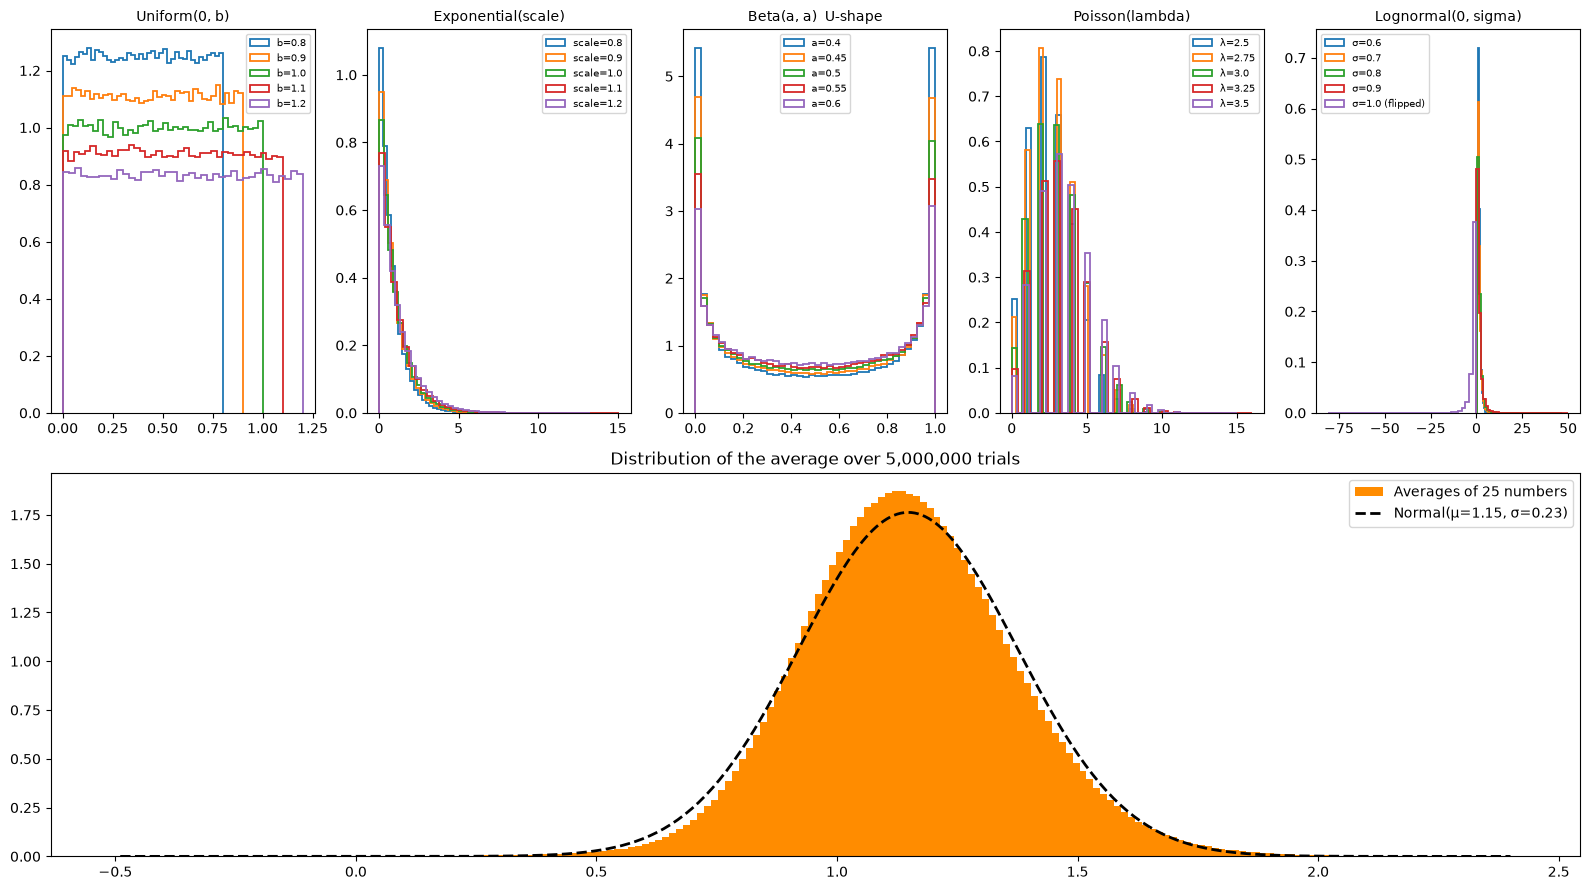

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N_TRIALS = 5_000_000
N_SHOW = 200_000          # how many samples to use for the top-row histograms

# 5 families x 5 slightly different parameter values = 25 distributions
families = {
    "Uniform(0, b)": {
        "params": [0.8, 0.9, 1.0, 1.1, 1.2],
        "sample": lambda p, n: rng.uniform(0, p, n),
        "label":  lambda p: f"b={p}",
    },
    "Exponential(scale)": {
        "params": [0.8, 0.9, 1.0, 1.1, 1.2],
        "sample": lambda p, n: rng.exponential(p, n),
        "label":  lambda p: f"scale={p}",
    },
    "Beta(a, a)  U-shape": {
        "params": [0.40, 0.45, 0.50, 0.55, 0.60],
        "sample": lambda p, n: rng.beta(p, p, n),
        "label":  lambda p: f"a={p}",
    },
    "Poisson(lambda)": {
        "params": [2.5, 2.75, 3.0, 3.25, 3.5],
        "sample": lambda p, n: rng.poisson(p, n),
        "label":  lambda p: f"λ={p}",
    },
    "Lognormal(0, sigma)": {
        "params": [0.6, 0.7, 0.8, 0.9, 1.0],
        "sample": lambda p, n: rng.lognormal(0, p, n),
        "label":  lambda p: f"σ={p}",
        "flip_params": [1.0],   # mirror (x -> -x) this variant so its right skew cancels the others
    },
}

# Each trial: draw ONE number from each of the 25 distributions, then average them.
# We keep a running sum so we never store a (5,000,000 x 25) array in memory.
total = np.zeros(N_TRIALS)
n_dists = 0
shown = {}   # small samples kept only for the top-row plots

for fam_name, fam in families.items():
    shown[fam_name] = []
    for p in fam["params"]:
        x = fam["sample"](p, N_TRIALS)
        flipped = p in fam.get("flip_params", [])
        if flipped:
            x = -x
        total += x
        n_dists += 1
        label = fam["label"](p) + (" (flipped)" if flipped else "")
        shown[fam_name].append((label, x[:N_SHOW]))

averages = total / n_dists
print(f"Averaged {n_dists} numbers per trial, {N_TRIALS:,} trials")

# --- Plot ---
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 5)

# Top row: one panel per family, overlaying its 5 parameter variants
for i, (fam_name, variants) in enumerate(shown.items()):
    ax = fig.add_subplot(gs[0, i])
    for label, data in variants:
        ax.hist(data, bins=40, density=True, histtype="step", lw=1.3, label=label)
    ax.set_title(fam_name, fontsize=10)
    ax.legend(fontsize=7)

# Bottom row: histogram of the averages + normal curve with the same mean/std
ax = fig.add_subplot(gs[1, :])
lo, hi = np.percentile(averages, [0.01, 99.99])   # zoom past rare extreme values
ax.hist(averages, bins=200, range=(lo, hi), density=True, color="darkorange",
        label=f"Averages of {n_dists} numbers")

mu, sigma = averages.mean(), averages.std()
x = np.linspace(lo, hi, 400)
pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, pdf, "k--", lw=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")

ax.set_title(f"Distribution of the average over {N_TRIALS:,} trials")
ax.legend()

plt.tight_layout()
plt.savefig("clt_demo_25.png", dpi=120)
plt.show()

# Moments, MGF, Skewness, Kurtosis, Cumulants and the Characteristic Function

A step-by-step guide with proofs. It is written so that nothing is skipped: every formula is derived from something defined earlier.

**Notation used everywhere**

- `X, Y` are random variables. `E[...]` means expected value (average). `Var` means variance.
- `μ = E[X]` is the mean and `σ² = Var(X)` is the variance.
- `i` is the imaginary unit with `i² = -1`.
- `iid` means independent and identically distributed.

---

## Table of contents

1. Prerequisites you need first
2. Moments (raw, central, standardized)
3. The Moment Generating Function (MGF)
4. Worked MGF examples
5. What you can get out of an MGF
6. Where the MGF fails
7. Cumulants and the Cumulant Generating Function
8. Skewness, kurtosis, excess kurtosis and other terms
9. The Characteristic Function (CF)
10. CF properties with proofs
11. Worked CF examples
12. Inversion, uniqueness and Lévy's continuity theorem
13. The CLT proof using the CF
14. MGF vs CF cheat sheet
15. Code to check everything numerically

---

## 1. Prerequisites you need first

### 1.1 Expected value

For a discrete variable with probabilities `p(x)`:

```
E[X] = Σ x · p(x)
```

For a continuous variable with density `f(x)`:

```
E[X] = ∫ x · f(x) dx
```

### 1.2 Expected value of a function (LOTUS)

To get `E[g(X)]` you do not need the distribution of `g(X)`. You just plug `g` inside:

```
E[g(X)] = Σ g(x) p(x)        (discrete)
E[g(X)] = ∫ g(x) f(x) dx     (continuous)
```

This is how we compute `E[X²]`, `E[e^{tX}]` and `E[e^{itX}]` below.

### 1.3 Linearity

```
E[aX + bY + c] = a·E[X] + b·E[Y] + c
```

This holds always, with no independence needed.

### 1.4 Independence and products

If `X` and `Y` are independent, then for any functions `g` and `h`:

```
E[g(X) · h(Y)] = E[g(X)] · E[h(Y)]
```

This one fact is what makes MGFs and CFs so powerful for sums.

### 1.5 The exponential series

For any real or complex number `x`:

```
e^x = 1 + x + x²/2! + x³/3! + x⁴/4! + ...  =  Σ_{k=0}^{∞} x^k / k!
```

### 1.6 Variance in terms of moments

```
Var(X) = E[(X − μ)²]
       = E[X² − 2μX + μ²]
       = E[X²] − 2μ·E[X] + μ²          (linearity)
       = E[X²] − 2μ² + μ²
       = E[X²] − μ²
```

### 1.7 Covariance and variance of a sum

```
Cov(X, Y) = E[(X − μ_X)(Y − μ_Y)] = E[XY] − E[X]E[Y]
Corr(X, Y) = Cov(X, Y) / (σ_X σ_Y)           always between −1 and +1
Var(X + Y) = Var(X) + Var(Y) + 2·Cov(X, Y)
```

If `X` and `Y` are independent, then `E[XY] = E[X]E[Y]` (from 1.4), so `Cov = 0` and `Var(X + Y) = Var(X) + Var(Y)`. The converse is false: zero covariance does not imply independence.

---

## 2. Moments

### 2.1 Definitions

| Name | Formula | Meaning |
|---|---|---|
| k-th **raw moment** | `m'_k = E[X^k]` | average of the k-th power |
| k-th **central moment** | `m_k = E[(X − μ)^k]` | average of the k-th power of the distance from the mean |
| k-th **standardized moment** | `m_k / σ^k` | central moment made unit-free |

Special cases:

- `m'_1 = μ` (mean)
- `m_1 = 0` always, because `E[X − μ] = μ − μ = 0`
- `m_2 = σ²` (variance)
- `m_3 / σ³` = **skewness**
- `m_4 / σ⁴` = **kurtosis**

### 2.2 Why moments describe the shape

- 1st moment: where the distribution sits (location).
- 2nd central moment: how wide it is (spread).
- 3rd central moment: whether one tail is longer than the other (asymmetry). The cube keeps the sign, so left deviations count negative and right deviations count positive.
- 4th central moment: how heavy the tails are. The fourth power makes far-away values count enormously.

### 2.3 Converting raw moments to central moments

Expand `(X − μ)^k` with the binomial theorem and use linearity. Write `E[X^j]` as `m'_j`.

**Third central moment**

```
m_3 = E[(X − μ)³]
    = E[X³ − 3μX² + 3μ²X − μ³]
    = m'_3 − 3μ·m'_2 + 3μ²·μ − μ³
    = m'_3 − 3μ·m'_2 + 2μ³
```

**Fourth central moment**

```
m_4 = E[(X − μ)⁴]
    = E[X⁴ − 4μX³ + 6μ²X² − 4μ³X + μ⁴]
    = m'_4 − 4μ·m'_3 + 6μ²·m'_2 − 4μ³·μ + μ⁴
    = m'_4 − 4μ·m'_3 + 6μ²·m'_2 − 3μ⁴
```

---

## 3. The Moment Generating Function (MGF)

### 3.1 The idea

We would like to store **all** moments `E[X], E[X²], E[X³], ...` of a variable in **one** function, and get any of them back when needed. That function is called a *generating function*, and for moments it is the MGF.

### 3.2 Definition

```
M_X(t) = E[ e^{tX} ]
```

Here `t` is a real number. For a continuous variable this is `∫ e^{tx} f(x) dx`, and for a discrete one it is `Σ e^{tx} p(x)`.

**Existence condition.** The MGF is said to exist only if `M_X(t)` is finite for all `t` in some open interval `(−h, h)` around 0 with `h > 0`. It is not enough to be finite only at `t = 0` (where it always equals 1).

### 3.3 Why `e^{tX}` stores the moments

Use the exponential series (1.5) with `x = tX`:

```
e^{tX} = 1 + tX + t²X²/2! + t³X³/3! + ...
```

Take expectations term by term:

```
M_X(t) = 1 + t·E[X] + t²·E[X²]/2! + t³·E[X³]/3! + ...
       = Σ_{k=0}^{∞}  E[X^k] · t^k / k!
```

So the moments appear as coefficients of the power series of `M_X`. The `k!` is the "price" of packing them in, and it is why it is called "generating".

### 3.4 Theorem: moments come from derivatives at 0

**Statement.** If `M_X(t)` exists on `(−h, h)`, then all moments are finite and

```
E[X^k] = M_X^{(k)}(0)      (the k-th derivative of M at t = 0)
```

**Proof.**

*Step 1: swap the expectation and the sum.* We want to push `E` through the infinite sum in 3.3. This is allowed (Fubini/Tonelli theorem) when the sum of absolute values has finite expectation:

```
Σ_k |tX|^k / k!  =  e^{|tX|}
E[e^{|tX|}]  ≤  E[e^{tX} + e^{−tX}]  =  M(t) + M(−t)  <  ∞    for |t| < h
```

The inequality holds because `e^{|y|}` equals either `e^{y}` or `e^{−y}`, and both are positive. Since the right-hand side is finite, the swap is valid, which also proves that `E[|X|^k] < ∞` for every k.

*Step 2: identify the coefficients.* After the swap,

```
M(t) = Σ_k  [E[X^k] / k!] · t^k
```

*Step 3: differentiate the power series.* Inside its radius of convergence a power series can be differentiated term by term. Differentiating k times and setting `t = 0` kills every term except the k-th:

```
M^{(k)}(0) = k! × (coefficient of t^k) = k! × E[X^k]/k! = E[X^k]        ∎
```

**Quick intuition version (first derivative).** Differentiating inside the expectation:

```
d/dt E[e^{tX}] = E[ X · e^{tX} ]   →   at t = 0:  E[X · 1] = E[X]
```

and the second derivative gives `E[X² e^{tX}]`, which at 0 is `E[X²]`.

### 3.5 Basic properties, each with proof

**(a) `M(0) = 1`.** Because `e^{0·X} = 1` and `E[1] = 1`.

**(b) Linear transformation.** For `Y = aX + b`:

```
M_Y(t) = E[e^{t(aX + b)}] = e^{bt} · E[e^{(at)X}] = e^{bt} · M_X(at)
```

**(c) Sum of independent variables (the key property).** If `X` and `Y` are independent:

```
M_{X+Y}(t) = E[e^{t(X+Y)}]
           = E[e^{tX} · e^{tY}]          (exponent rule)
           = E[e^{tX}] · E[e^{tY}]       (independence, section 1.4)
           = M_X(t) · M_Y(t)
```

For `n` independent variables, the MGF of the sum is the product of the n MGFs. For `n` iid copies it is `[M_X(t)]^n`. This replaces the painful convolution of densities with a simple product.

**(d) Uniqueness theorem (stated).** If `M_X(t) = M_Y(t)` for all `t` in some interval `(−h, h)`, then `X` and `Y` have the same distribution.

*Why it is true (idea).* A function given by a convergent power series is analytic, so it extends to complex `t`. On the imaginary axis it becomes the characteristic function (section 9), and the characteristic function determines the distribution (section 12).

**(e) Continuity theorem (stated).** If `M_{X_n}(t) → M_X(t)` for all `t` in an interval around 0, then `X_n` converges in distribution to `X`.

---

## 4. Worked MGF examples

### 4.1 Bernoulli(p)

`X = 1` with probability `p`, `X = 0` otherwise.

```
M(t) = e^{t·0}(1 − p) + e^{t·1}·p = 1 − p + p·e^t
```

**Binomial(n, p)** is a sum of n independent Bernoulli(p), so by property (c):

```
M(t) = (1 − p + p·e^t)^n
```

### 4.2 Poisson(λ)

```
M(t) = Σ_{k=0}^{∞} e^{tk} · e^{−λ} λ^k / k!
     = e^{−λ} · Σ (λ e^t)^k / k!
     = e^{−λ} · exp(λ e^t)                (exponential series with x = λe^t)
     = exp( λ (e^t − 1) )
```

Moments from derivatives:

```
M'(t)  = λ e^t · M(t)                          → M'(0)  = λ         = mean
M''(t) = λ e^t · M(t) + (λ e^t)² · M(t)        → M''(0) = λ + λ²    = E[X²]
Var = E[X²] − μ² = λ + λ² − λ² = λ
```

**Sum of independent Poissons is Poisson.** For `X ~ Poisson(λ₁)` and `Y ~ Poisson(λ₂)` independent:

```
M_{X+Y}(t) = exp(λ₁(e^t − 1)) · exp(λ₂(e^t − 1)) = exp((λ₁ + λ₂)(e^t − 1))
```

That is the MGF of Poisson(λ₁ + λ₂), so by uniqueness `X + Y ~ Poisson(λ₁ + λ₂)`.

### 4.3 Exponential(rate λ)

Density `f(x) = λ e^{−λx}` for `x ≥ 0`.

```
M(t) = ∫₀^∞ e^{tx} λ e^{−λx} dx
     = λ ∫₀^∞ e^{−(λ − t)x} dx
     = λ · [ 1/(λ − t) ]            valid only when t < λ
     = λ / (λ − t)
```

Note that it exists only for `t < λ`, which is still an interval around 0, so it qualifies.

Get all moments by expanding:

```
λ/(λ − t) = 1/(1 − t/λ) = Σ (t/λ)^k           (geometric series)
```

Compare with `Σ E[X^k] t^k / k!`:

```
E[X^k] / k! = 1/λ^k    →    E[X^k] = k! / λ^k
```

So `E[X] = 1/λ`, `E[X²] = 2/λ²`, `E[X³] = 6/λ³`, `E[X⁴] = 24/λ⁴`. Using the formulas from 2.3 with `μ = 1/λ`:

```
m_3 = 6/λ³ − 3(1/λ)(2/λ²) + 2/λ³ = 2/λ³
m_4 = 24/λ⁴ − 4(1/λ)(6/λ³) + 6(1/λ²)(2/λ²) − 3/λ⁴ = 9/λ⁴
σ² = 1/λ²
Skewness = m_3/σ³ = 2          Kurtosis = m_4/σ⁴ = 9      Excess = 6
```

### 4.4 Standard normal N(0, 1)

```
M(t) = ∫ e^{tx} · (1/√(2π)) e^{−x²/2} dx
     = ∫ (1/√(2π)) e^{−(x² − 2tx)/2} dx
```

Complete the square: `x² − 2tx = (x − t)² − t²`. Therefore

```
M(t) = e^{t²/2} · ∫ (1/√(2π)) e^{−(x − t)²/2} dx
     = e^{t²/2} · 1                         (the integral is a normal density, total area 1)
     = e^{t²/2}
```

**All moments of the standard normal.** Expand `e^{t²/2}` with the exponential series:

```
e^{t²/2} = Σ_k (t²/2)^k / k! = Σ_k  t^{2k} / (2^k · k!)
```

Only even powers appear, so all odd moments are 0. Matching coefficients of `t^{2k}`:

```
E[Z^{2k}] / (2k)! = 1/(2^k k!)    →    E[Z^{2k}] = (2k)! / (2^k k!) = (2k − 1)!!
```

So `E[Z²] = 1`, `E[Z⁴] = 3`, `E[Z⁶] = 15`. Hence the normal has skewness 0 and kurtosis 3, which is why we subtract 3 to get "excess" kurtosis.

**General normal N(μ, σ²).** Write `X = μ + σZ` and use property (b):

```
M_X(t) = e^{μt} · M_Z(σt) = exp( μt + σ²t²/2 )
```

Check by derivatives:

```
M'(t)  = (μ + σ²t) · M(t)              → M'(0)  = μ
M''(t) = σ² M(t) + (μ + σ²t)² M(t)     → M''(0) = σ² + μ²   → Var = σ²
```

**Sum of independent normals is normal.** For independent `N(μ₁,σ₁²)` and `N(μ₂,σ₂²)`:

```
M_{X+Y}(t) = exp((μ₁+μ₂)t + (σ₁²+σ₂²)t²/2)
```

This is the MGF of `N(μ₁+μ₂, σ₁²+σ₂²)`, so the sum is normal with those parameters.

### 4.5 Uniform(0, 1)

```
M(t) = ∫₀¹ e^{tx} dx = (e^t − 1)/t        (and M(0) = 1)
```

---

## 5. What you can get out of an MGF

1. **Moments:** `E[X^k] = M^{(k)}(0)`.
2. **Mean and variance:** `μ = M'(0)`, `σ² = M''(0) − M'(0)²`.
3. **Distribution of sums of independent variables:** multiply MGFs, then recognize the result (via uniqueness).
4. **Identification of a distribution:** two variables with the same MGF (on an interval) are the same distribution.
5. **Convergence in distribution:** if MGFs converge, the distributions converge (continuity theorem).
6. **Cumulants, hence skewness and kurtosis:** by taking `ln M` (section 7).
7. **Tail bounds (Chernoff bound):** for any `t > 0`,

```
P(X ≥ a) = P(e^{tX} ≥ e^{ta})
         ≤ E[e^{tX}] / e^{ta}               (Markov's inequality applied to e^{tX} ≥ 0)
         = e^{−ta} · M(t)
```

and you can choose `t` to make the bound as small as possible. For `Z ~ N(0,1)`: the bound is `e^{−ta + t²/2}`. Its exponent is minimized at `t = a`, giving `P(Z ≥ a) ≤ e^{−a²/2}`.

---

## 6. Where the MGF fails

The MGF needs `E[e^{tX}]` finite near 0. This breaks for heavy-tailed variables.

- **Cauchy:** it does not even have a mean, so no MGF.
- **Lognormal:** all moments exist, but `E[e^{tX}] = ∞` for **every** `t > 0`. The reason is that `X = e^{σZ}` makes `e^{tX} = exp(t·e^{σZ})`, a double exponential in `Z`, which grows faster than the normal density `e^{−z²/2}` decays.
- Worse, for the lognormal the sequence of moments does **not** even determine the distribution (a classical counterexample: different distributions with identical moments exist). So "same moments" does not imply "same distribution" in general.

This is why we need something that always exists. That is the characteristic function (section 9).

---

## 7. Cumulants and the Cumulant Generating Function

### 7.1 Definition

```
K_X(t) = ln M_X(t)            (cumulant generating function, CGF)
κ_r    = K_X^{(r)}(0)         (r-th cumulant)
```

Equivalently, `K(t) = Σ κ_r t^r / r!`.

### 7.2 Why cumulants are useful

**Property 1: cumulants of independent sums add.** From 3.5(c): `M_{X+Y} = M_X · M_Y`. Taking logs turns the product into a sum:

```
K_{X+Y}(t) = K_X(t) + K_Y(t)    →    κ_r(X + Y) = κ_r(X) + κ_r(Y)
```

**Property 2: scaling.** `K_{cX}(t) = ln M_X(ct) = K_X(ct)`, so `κ_r(cX) = c^r · κ_r(X)`.

**Property 3: shifting only changes κ₁.** `K_{X+b}(t) = K_X(t) + bt`, and `bt` is a linear term, so only `κ₁` changes (by `b`). All cumulants with `r ≥ 2` are shift-invariant.

**Property 4: normal has no cumulants beyond 2.** For `N(μ, σ²)`: `K(t) = μt + σ²t²/2`, so `κ₁ = μ`, `κ₂ = σ²`, and `κ_r = 0` for `r ≥ 3`. That is why skewness and excess kurtosis measure "departure from normal".

### 7.3 What the first four cumulants are

**First two via derivatives.**

```
K'(t)  = M'(t) / M(t)                     → K'(0)  = E[X] / 1 = μ              = κ₁
K''(t) = [M''M − (M')²] / M²              → K''(0) = E[X²] − μ² = σ²           = κ₂
```

**κ₃ and κ₄ via series (cleanest route).** By Property 3, `κ_r` for `r ≥ 2` is unchanged if we center the variable. Let `Y = X − μ`, which has `m_1 = 0`. Its MGF series is

```
M_Y(t) = 1 + u,    u = m_2 t²/2 + m_3 t³/6 + m_4 t⁴/24 + ...
```

Use `ln(1 + u) = u − u²/2 + u³/3 − ...`. Up to order `t⁴`, only `u` and `u²` contribute, and `u² = m_2² t⁴/4 + (higher order)`. So

```
K_Y(t) = m_2 t²/2 + m_3 t³/6 + ( m_4/24 − m_2²/8 ) t⁴ + O(t⁵)
```

Now match with `K(t) = Σ κ_r t^r / r!`:

```
κ₂ = 2! × (m_2/2)            = m_2
κ₃ = 3! × (m_3/6)            = m_3
κ₄ = 4! × (m_4/24 − m_2²/8)  = m_4 − 3·m_2²
```

**Summary**

| Cumulant | Equals |
|---|---|
| κ₁ | mean |
| κ₂ | variance `σ²` |
| κ₃ | third central moment `m_3` |
| κ₄ | `m_4 − 3σ⁴` |

So:

```
Skewness        γ₁ = κ₃ / κ₂^{3/2}
Excess kurtosis γ₂ = κ₄ / κ₂²
```

Check: `κ₄/κ₂² = (m_4 − 3σ⁴)/σ⁴ = m_4/σ⁴ − 3 = kurtosis − 3`. ✓

### 7.4 Examples

**Poisson(λ):** `K(t) = λ(e^t − 1) = λ Σ_{k≥1} t^k/k!`, so every `κ_r = λ`. Skewness `= λ/λ^{3/2} = 1/√λ`, excess kurtosis `= λ/λ² = 1/λ`.

**Exponential(λ):** `K(t) = ln λ − ln(λ − t) = −ln(1 − t/λ) = Σ_{k≥1} (t/λ)^k / k`, so `κ_r = (r − 1)!/λ^r`. Then `κ₂ = 1/λ²`, `κ₃ = 2/λ³`, `κ₄ = 6/λ⁴`, so skewness `= 2` and excess kurtosis `= 6`. This matches the direct computation in 4.3. ✓

### 7.5 Why skewness shrinks like 1/√n and kurtosis like 1/n

Let `X₁,...,X_n` be iid with cumulants `κ_r`, and let `S = ΣX_j`. By Property 1, `κ_r(S) = n·κ_r`. Standardize:

```
Z = (S − nμ) / (σ√n)
```

By Properties 2 and 3 (for `r ≥ 3`):

```
κ_r(Z) = κ_r(S) / (σ√n)^r = n·κ_r / (σ^r · n^{r/2}) = n^{1 − r/2} · (κ_r / σ^r)
```

- `r = 3`: skewness of Z `= γ₁(X) / √n`
- `r = 4`: excess kurtosis of Z `= γ₂(X) / n`
- `r ≥ 3` in general: exponent `1 − r/2 < 0`, so every higher cumulant goes to 0 while `κ₂(Z) = 1` stays, which is exactly a standard normal.

**MGF version of the CLT (valid when the MGF exists):**

```
K_Z(t) = n · K_Y(t/√n)         (Y = standardized single variable)
       = n · [ t²/(2n) + κ₃' t³/(6 n^{3/2}) + ... ]
       = t²/2 + κ₃' t³/(6√n) + ...    →    t²/2
```

So `M_Z(t) → e^{t²/2}`, the MGF of N(0,1). The characteristic-function version in section 13 needs no MGF at all.

---

## 8. Skewness, kurtosis, excess kurtosis and other terms

### 8.1 Skewness

```
γ₁ = E[(X − μ)³] / σ³
```

| Value | Meaning |
|---|---|
| `γ₁ = 0` | symmetric (or balanced tails) |
| `γ₁ > 0` | long **right** tail (a few huge values), mean is usually above the median |
| `γ₁ < 0` | long **left** tail |

Why divide by `σ³`? To make it unit-free. Multiplying `X` by `c` multiplies `m_3` by `c³` and `σ³` by `c³`, so skewness does not change. Symmetric distributions have skewness 0 (if the third moment exists), but zero skewness does not guarantee symmetry.

### 8.2 Kurtosis and excess kurtosis

```
Kurtosis        = E[(X − μ)⁴] / σ⁴
Excess kurtosis = Kurtosis − 3
```

The normal has kurtosis 3, so excess kurtosis 0 means "same tail weight as a normal".

| Excess kurtosis | Name | Meaning |
|---|---|---|
| `< 0` | platykurtic | lighter tails than normal (e.g., uniform) |
| `= 0` | mesokurtic | normal |
| `> 0` | leptokurtic | heavier tails and more outliers (e.g., exponential, Laplace) |

**Important misconception.** Kurtosis is **not** really "peakedness". Because of the fourth power, it is dominated by the extreme tails: a few far-out values contribute far more than the bulk. It measures **tendency to produce outliers**.

Limits: kurtosis is always `≥ 1 + γ₁²`, so excess kurtosis `≥ −2` (reached by a fair coin, Bernoulli(1/2)).

### 8.3 Reference table

| Distribution | Skewness | Excess kurtosis |
|---|---|---|
| Normal | 0 | 0 |
| Uniform | 0 | −1.2 |
| Exponential | 2 | 6 |
| Laplace | 0 | 3 |
| Poisson(λ) | `1/√λ` | `1/λ` |
| Beta(a, a) | 0 | `−6/(2a + 3)` |
| Bernoulli(p) | `(1−2p)/√(p(1−p))` | `(1 − 6p(1−p)) / (p(1−p))` |
| Lognormal(0, σ) | `(e^{σ²} + 2)·√(e^{σ²} − 1)` | `e^{4σ²} + 2e^{3σ²} + 3e^{2σ²} − 6` |

Check: Beta(1,1) is the uniform, and `−6/(2·1+3) = −1.2` ✓.

### 8.4 Estimating them from data

With sample moments `m_k = (1/n) Σ (x_j − x̄)^k`:

```
sample skewness        g₁ = m_3 / m_2^{3/2}
sample excess kurtosis g₂ = m_4 / m_2² − 3
```

In scipy: `scipy.stats.skew(data)` and `scipy.stats.kurtosis(data)` (the latter returns **excess** kurtosis by default). Both are biased for small samples; the estimates are noisy for heavy-tailed data because they depend on rare extreme values.

### 8.5 Other terms you will meet

| Term | Definition |
|---|---|
| **PDF / PMF** | density `f(x)` (continuous) or probabilities `p(x)` (discrete) |
| **CDF** | `F(x) = P(X ≤ x)` |
| **Median** | value `m` with `P(X ≤ m) = 1/2` |
| **Mode** | most likely value (peak of the density) |
| **Quantile** | value below which a given fraction of the probability lies |
| **Standardization** | `Z = (X − μ)/σ`, giving mean 0 and variance 1 |
| **iid** | independent and identically distributed |
| **Covariance / correlation** | linear co-movement of two variables (section 1.7) |
| **Convergence in probability** | `P(|X_n − X| > ε) → 0` for every `ε > 0` |
| **Convergence in distribution** | `F_{X_n}(x) → F_X(x)` at every continuity point of `F_X`; this is the type of convergence in the CLT |
| **Law of Large Numbers (LLN)** | the sample mean `X̄_n → μ` as `n → ∞`; it says the average **converges to a number**, while the CLT describes the **shape of fluctuations around it** |

---

## 9. The Characteristic Function (CF)

### 9.1 Motivation

The MGF can fail to exist (section 6). We want a transform with the same good properties (product for sums, moments from derivatives, uniqueness) that **always exists**. The fix is to use an imaginary exponent: `e^{itX}` instead of `e^{tX}`.

### 9.2 A quick complex number primer

1. A complex number is `z = a + bi`, with `i² = −1`. Its conjugate is `z̄ = a − bi`. Its **modulus** is `|z| = √(a² + b²)`, and `|zw| = |z||w|`.
2. **Euler's formula:** `e^{iθ} = cos θ + i sin θ`.
   *Why:* put `x = iθ` in the exponential series. The powers of `i` cycle `i, −1, −i, 1, ...`, so the even terms give `1 − θ²/2! + θ⁴/4! − ... = cos θ` and the odd terms give `i(θ − θ³/3! + ...) = i sin θ`.
3. **Modulus is 1:** `|e^{iθ}|² = cos²θ + sin²θ = 1`. So `e^{iθ}` is a point on the unit circle. This single fact is why the CF never blows up.
4. **Exponent rule:** `e^{i(α+β)} = e^{iα} · e^{iβ}`. This follows from the angle-addition formulas for sine and cosine.
5. **Expectation of a complex variable:** `E[U + iV] = E[U] + i·E[V]`.
6. **Triangle inequality for expectations:** `|E[Z]| ≤ E[|Z|]` for complex `Z`.
   *Proof:* write `E[Z] = r·e^{iα}` with `r = |E[Z]|`. Then `r = e^{−iα}E[Z] = E[e^{−iα}Z]`. Since `r` is real, `r = E[Re(e^{−iα}Z)] ≤ E[|e^{−iα}Z|] = E[|Z|]`. ∎

### 9.3 Definition

```
φ_X(t) = E[ e^{itX} ] = E[cos(tX)] + i · E[sin(tX)]
```

For a continuous variable: `φ(t) = ∫ e^{itx} f(x) dx`. This is the **Fourier transform** of the density.

### 9.4 Intuition

For each frequency `t`, the variable `X` is "wrapped" around the unit circle: the value `x` is mapped to the point `e^{itx}`. The CF is the **average position** of those points. A wide, spread-out distribution wraps all over the circle and the points cancel out (CF near 0 for big `t`). A narrow distribution keeps the points clustered (CF stays near 1). So the decay of `φ(t)` reflects how smooth and how spread the distribution is.

### 9.5 Why it always exists

`|e^{itX}| = 1` for every outcome, so `E[e^{itX}]` is an average of bounded numbers, and by 9.2(6) `|φ(t)| ≤ 1`. No moment conditions are needed at all, which is why even the Cauchy has a CF.

---

## 10. CF properties with proofs

### (a) `φ(0) = 1`

`e^{i·0·X} = 1`, so `φ(0) = E[1] = 1`.

### (b) `|φ(t)| ≤ 1` for all `t`

```
|φ(t)| = |E[e^{itX}]| ≤ E[|e^{itX}|] = E[1] = 1       (by 9.2 items 6 and 3)
```

### (c) Conjugate symmetry: `φ(−t) = conj(φ(t))`

```
φ(−t) = E[cos(−tX) + i sin(−tX)] = E[cos(tX)] − i·E[sin(tX)] = conj(φ(t))
```

using that cosine is even and sine is odd.

**Corollary.** If `X` is symmetric about 0 (that is, `X` and `−X` have the same distribution), then `E[sin(tX)] = 0` (an odd function averaged over a symmetric distribution), so `φ(t)` is **real**. Conversely, an imaginary part signals asymmetry (skewness).

### (d) Shift and scale: `Y = aX + b`

```
φ_Y(t) = E[e^{it(aX + b)}] = e^{itb} · E[e^{i(at)X}] = e^{itb} · φ_X(at)
```

### (e) Sum of independent variables

For independent `X`, `Y`, write `c_X = cos(tX)`, `s_X = sin(tX)`, and similarly for `Y`. Functions of independent variables are independent, so `E[c_X c_Y] = E[c_X]E[c_Y]` and so on:

```
φ_{X+Y}(t) = E[ (c_X + i s_X)(c_Y + i s_Y) ]
           = E[c_X c_Y] − E[s_X s_Y] + i( E[c_X s_Y] + E[s_X c_Y] )
           = (E c_X · E c_Y − E s_X · E s_Y) + i(E c_X · E s_Y + E s_X · E c_Y)
           = (E c_X + i E s_X)(E c_Y + i E s_Y)
           = φ_X(t) · φ_Y(t)
```

For `n` iid copies: `φ_{ΣX}(t) = [φ_X(t)]^n`.

### (f) Uniform continuity

```
|φ(t + h) − φ(t)| = |E[e^{itX}(e^{ihX} − 1)]| ≤ E[ |e^{ihX} − 1| ]
```

The right side does not depend on `t`. As `h → 0`, `|e^{ihX} − 1| → 0` for every outcome and it is bounded by 2, so by the dominated convergence theorem the expectation goes to 0. So `φ` is uniformly continuous on the whole real line.

### (g) Key lemma: Taylor expansion of `e^{ix}` with an explicit error bound

Define the remainder `R_n(x) = e^{ix} − Σ_{k=0}^{n} (ix)^k / k!`.

**Claim:** `|R_n(x)| ≤ min( |x|^{n+1}/(n+1)! , 2|x|^n/n! )`.

*Proof.* Differentiate:

```
R_n'(x) = i·e^{ix} − Σ_{k=1}^{n} i·(ix)^{k−1}/(k−1)!
        = i · [ e^{ix} − Σ_{j=0}^{n−1} (ix)^j/j! ]
        = i · R_{n−1}(x)
```

and `R_n(0) = 0`, so `R_n(x) = i ∫₀^x R_{n−1}(s) ds`.

- Start: `R_0(x) = e^{ix} − 1`. We have `|R_0(x)| ≤ |x|` (the chord is no longer than the arc) and `|R_0(x)| ≤ 2` (two points on the unit circle).
- Each step `R_n(x) = i ∫₀^x R_{n−1}(s) ds` integrates the bound once more, which divides by one more factor. Starting from `|R_0(s)| ≤ |s|` gives `|R_1| ≤ x²/2`, `|R_2| ≤ |x|³/6`, and in general `|R_n(x)| ≤ |x|^{n+1}/(n+1)!`. Starting from `|R_0(s)| ≤ 2` gives `|R_1| ≤ 2|x|`, `|R_2| ≤ x²`, and in general `|R_n(x)| ≤ 2|x|^n/n!`. Both bounds hold, so the smaller one holds. ∎

### (h) Moments from derivatives

**Statement.** If `E|X|^k < ∞`, then `φ` is k times differentiable and `φ^{(k)}(0) = i^k · E[X^k]`.

*Proof for k = 1.*

```
[φ(t + h) − φ(t)] / h = E[ e^{itX} · (e^{ihX} − 1)/h ]
```

Since `|e^{ix} − 1| ≤ |x|`, the integrand is bounded in modulus by `|X|`, which is integrable. And `(e^{ihX} − 1)/h → iX` as `h → 0`. By dominated convergence:

```
φ'(t) = E[ iX · e^{itX} ]      →      φ'(0) = i · E[X]
```

Repeating the same argument k times gives `φ^{(k)}(t) = E[(iX)^k e^{itX}]` and `φ^{(k)}(0) = i^k E[X^k]`. ∎

Compared with the MGF formula `M^{(k)}(0) = E[X^k]`, the only new thing is the factor `i^k`.

### (i) Taylor expansion of `φ` itself

If `E|X|^n < ∞`:

```
φ(t) = Σ_{k=0}^{n} (it)^k E[X^k] / k!  +  o(t^n)       as t → 0
```

*Proof.* By lemma (g), `φ(t) − Σ... = E[R_n(tX)]`. Then

```
|E[R_n(tX)]| / |t|^n ≤ E[ min( |t||X|^{n+1}/(n+1)! , 2|X|^n/n! ) ]
```

As `t → 0` the inner minimum tends to 0 pointwise and is dominated by `2|X|^n/n!`, which is integrable. By dominated convergence the whole thing tends to 0. ∎

This needs **only n finite moments**, not an infinite series. That is exactly why the CLT needs only a finite variance.

### (j) Relation to the MGF

When the MGF exists, `φ(t) = M(it)`: just substitute `t → it`. Example: `M(t) = e^{t²/2}` gives `φ(t) = e^{(it)²/2} = e^{−t²/2}`.

---

## 11. Worked CF examples

### 11.1 Bernoulli(p)

```
φ(t) = (1 − p) + p·e^{it}
```

and Binomial(n,p) is `(1 − p + p·e^{it})^n` by property (e).

### 11.2 Poisson(λ)

Same computation as the MGF, with `e^{it}` in place of `e^t`:

```
φ(t) = exp( λ (e^{it} − 1) )
```

### 11.3 Exponential(rate λ)

```
φ(t) = ∫₀^∞ e^{itx} λ e^{−λx} dx = λ ∫₀^∞ e^{−(λ − it)x} dx = λ / (λ − it)
```

The integral converges because `|e^{−(λ−it)x}| = e^{−λx} → 0`.

### 11.4 Uniform(−a, a)

```
φ(t) = (1/2a) ∫_{−a}^{a} e^{itx} dx = (1/2a) · (e^{ita} − e^{−ita}) / (it) = sin(at) / (at)
```

using `e^{iθ} − e^{−iθ} = 2i sin θ`.

### 11.5 Standard normal (derived with an ODE)

The density `f(x) = e^{−x²/2}/√(2π)` satisfies `f'(x) = −x·f(x)`.

```
φ'(t) = ∫ ix · e^{itx} f(x) dx                   (differentiate inside the integral)
      = −i ∫ e^{itx} f'(x) dx                    (replace x·f(x) by −f'(x))
```

Integrate by parts, `∫ e^{itx} f'(x) dx = [e^{itx} f(x)] − ∫ it·e^{itx} f(x) dx`. The boundary term is 0 because `f → 0` at ±∞, so this integral equals `−it·φ(t)`. Therefore

```
φ'(t) = −i · ( −it · φ(t) ) = i² · t · φ(t) = −t · φ(t),      φ(0) = 1
```

Solve: `φ'/φ = −t`, so `ln φ = −t²/2 + C`, and `φ(0) = 1` gives `C = 0`:

```
φ(t) = e^{−t²/2}
```

For `N(μ, σ²)`, use property (d) with `X = μ + σZ`:

```
φ(t) = exp( iμt − σ²t²/2 )
```

### 11.6 Cauchy (why the CLT fails)

The standard Cauchy has density `1/(π(1 + x²))` and CF

```
φ(t) = e^{−|t|}
```

(derived with contour integration in complex analysis). For an average of `n` iid Cauchy variables:

```
φ_{X̄}(t) = [φ(t/n)]^n = [e^{−|t|/n}]^n = e^{−|t|}
```

That is the same CF, so **the average of n Cauchy variables is again exactly Cauchy**, for every `n`. Averaging does nothing. The CLT fails because the Cauchy has no finite variance (not even a finite mean).

### 11.7 Sum of independent normals via CF

```
φ_{X+Y}(t) = e^{iμ₁t − σ₁²t²/2} · e^{iμ₂t − σ₂²t²/2} = e^{i(μ₁+μ₂)t − (σ₁²+σ₂²)t²/2}
```

which is the CF of `N(μ₁+μ₂, σ₁²+σ₂²)`.

---

## 12. Inversion, uniqueness and Lévy's continuity theorem

### 12.1 Uniqueness

**Theorem.** If `φ_X(t) = φ_Y(t)` for all real `t`, then `X` and `Y` have the same distribution.

This is what lets us say "this CF belongs to a normal, so the variable is normal".

### 12.2 Inversion formula

If `∫ |φ(t)| dt < ∞`, then `X` has a continuous density given by

```
f(x) = (1/2π) ∫ e^{−itx} φ(t) dt
```

Check with the standard normal: `φ(t) = e^{−t²/2}`, so `f(x) = (1/2π) ∫ e^{−itx − t²/2} dt = (1/2π) · √(2π) · e^{−x²/2} = e^{−x²/2}/√(2π)` ✓ (a Gaussian integral).

For a general variable, the density may not exist, but Lévy's inversion formula recovers the CDF at continuity points `a < b`:

```
F(b) − F(a) = lim_{T→∞} (1/2π) ∫_{−T}^{T} [ (e^{−ita} − e^{−itb}) / (it) ] φ(t) dt
```

Since this formula recovers the distribution from `φ` alone, uniqueness follows.

### 12.3 Lévy's continuity theorem

**Statement.** Let `X_n` have CFs `φ_n`.

1. If `X_n → X` in distribution, then `φ_n(t) → φ_X(t)` for every `t`. (Reason: `cos(tx)` and `sin(tx)` are bounded continuous functions, and convergence in distribution means exactly that `E[g(X_n)] → E[g(X)]` for such `g`.)
2. If `φ_n(t) → g(t)` for every `t`, and `g` is **continuous at 0**, then `g` is the CF of some random variable `X` and `X_n → X` in distribution.

*Proof outline of part 2.* (i) Continuity of `g` at 0 forces the sequence `X_n` to be *tight* (no probability mass escapes to infinity), using the inequality `P(|X| ≥ 2/δ) ≤ (1/δ) ∫_{−δ}^{δ} (1 − φ(t)) dt`. (ii) A tight sequence has subsequences converging in distribution (Helly's selection theorem). (iii) By part 1 the limit of any such subsequence has CF `g`. (iv) By uniqueness all subsequential limits are the same distribution, so the entire sequence converges. ∎

---

## 13. The CLT proof using the CF

**Setup.** `X₁, X₂, ...` are iid with mean `μ` and finite variance `σ² > 0`.

### Step 1: standardize

Let `Y_j = (X_j − μ)/σ`. Then `E[Y_j] = 0` and `E[Y_j²] = 1`. Define

```
Z_n = (1/√n) (Y₁ + ... + Y_n) = (S_n − nμ) / (σ√n)
```

### Step 2: CF of Z_n

```
φ_{Z_n}(t) = E[ exp( i · (t/√n) · ΣY_j ) ]
           = E[ Π_j exp( i · (t/√n) · Y_j ) ]         (exponential of a sum = product)
           = Π_j E[ exp( i · (t/√n) · Y_j ) ]         (independence, property (e))
           = [ φ_Y(t/√n) ]^n                           (identical distribution)
```

### Step 3: expand φ_Y near 0

With `n = 2` in property (i), using `E[Y] = 0` and `E[Y²] = 1`:

```
φ_Y(s) = 1 + i·s·0 + (is)²·1/2 + o(s²) = 1 − s²/2 + o(s²)
```

Set `s = t/√n` for a fixed `t`:

```
φ_Y(t/√n) = 1 − t²/(2n) + ε_n,     with n · ε_n → 0
```

### Step 4: take the limit of the n-th power

We use the product inequality: if all complex numbers `a_j, b_j` have modulus ≤ 1, then `|Πa_j − Πb_j| ≤ Σ|a_j − b_j|`. (Proof by telescoping: `Πa − Πb = Σ_k a₁...a_{k−1}(a_k − b_k)b_{k+1}...b_n`, and each product has modulus ≤ 1.)

Take `a_j = φ_Y(t/√n)` (modulus ≤ 1 by property (b)) and `b_j = 1 − t²/(2n)` (in [0, 1] once `n ≥ t²/2`):

```
| [φ_Y(t/√n)]^n − [1 − t²/(2n)]^n |  ≤  n · |ε_n|  →  0
```

and the real limit `[1 − t²/(2n)]^n → e^{−t²/2}` follows from `(1 + a/n)^n → e^a` with `a = −t²/2`. Therefore, for every fixed `t`:

```
φ_{Z_n}(t) → e^{−t²/2}
```

### Step 5: identify the limit

`e^{−t²/2}` is the CF of N(0,1) (section 11.5) and is continuous at 0. By Lévy's continuity theorem, `Z_n → N(0,1)` in distribution. ∎

### Step 6: translate back

```
(S_n − nμ)/(σ√n) ≈ N(0, 1)     so     X̄_n ≈ N(μ, σ²/n)
```

### Step 7: speed of convergence (where skewness and kurtosis enter)

Taking logs of `φ_{Z_n}(t) = [φ_Y(t/√n)]^n` and expanding in cumulants of `Y` (valid for a finite number of moments):

```
ln φ_{Z_n}(t) = −t²/2  −  i·γ₁·t³/(6√n)  +  γ₂·t⁴/(24n)  +  ...
```

(using `i³ = −i`, `i⁴ = 1`). The correction terms are exactly the skewness term of order `1/√n` and the kurtosis term of order `1/n`. The **Berry–Esseen theorem** turns this into a rigorous bound: the largest gap between the CDF of `Z_n` and the normal CDF is at most `C · E|Y|³ / √n`, with a universal constant `C < 0.5`. So the error shrinks like `1/√n`, and it is larger when the third moment (skewed or heavy-tailed variables) is large.

### Step 8: different (non-identical) independent variables

Now `φ_{Z_n}(t) = Π_j φ_j(t/s_n)` where `s_n² = Σσ_j²`. Each factor is `1 − σ_j² t²/(2 s_n²) + small`, so the product of the main parts is `exp(−(t²/2) Σσ_j²/s_n²) = e^{−t²/2}`. The **Lindeberg condition** is exactly what guarantees that the "small" parts are negligible; informally, no single variable may carry a significant share of the total variance.

---

## 14. MGF vs CF cheat sheet

| | MGF | Characteristic function |
|---|---|---|
| Definition | `E[e^{tX}]` | `E[e^{itX}]` |
| Always exists? | No (needs light tails) | **Yes** |
| Bounded? | No | Yes, `|φ| ≤ 1` |
| Moments | `M^{(k)}(0) = E[X^k]` | `φ^{(k)}(0) = i^k E[X^k]` (if the moment is finite) |
| Sum of independent variables | product | product |
| Determines the distribution? | Yes (if it exists near 0) | **Always** |
| Convergence theorem | continuity theorem, needs MGF | Lévy's theorem, always applicable |
| Normal N(μ, σ²) | `e^{μt + σ²t²/2}` | `e^{iμt − σ²t²/2}` |
| Poisson(λ) | `exp(λ(e^t − 1))` | `exp(λ(e^{it} − 1))` |
| Exponential(λ) | `λ/(λ − t)`, `t < λ` | `λ/(λ − it)` |
| Cauchy | does not exist | `e^{−|t|}` |
| Log of it | cumulant generating function, `Σκ_r t^r/r!` | `Σ κ_r (it)^r/r!` |

**Mental map of the whole chain**

```
moments  →  MGF (stores moments, may not exist)
                ↓ ln
           cumulants (add for independent sums)  →  skewness = κ₃/κ₂^{3/2}, excess kurtosis = κ₄/κ₂²
                ↓
           characteristic function (always exists)  →  CLT proof via Lévy's theorem
```

---

## 15. Code to check everything numerically

### 15.1 Moments and cumulants from an MGF (symbolic)

```python
import sympy as sp

t = sp.symbols("t")
lam = sp.symbols("lambda", positive=True)

M = sp.exp(lam * (sp.exp(t) - 1))      # Poisson MGF
K = sp.log(M)                           # cumulant generating function

for k in range(1, 5):
    raw = sp.simplify(sp.diff(M, t, k).subs(t, 0))     # E[X^k]
    cum = sp.simplify(sp.diff(K, t, k).subs(t, 0))     # k-th cumulant
    print(f"k={k}:  E[X^k] = {sp.expand(raw)}     kappa_k = {cum}")
```

Expected: raw moments `λ`, `λ+λ²`, `λ³+3λ²+λ`, `λ⁴+6λ³+7λ²+λ`, and every cumulant equals `λ`.

### 15.2 Estimating skewness, kurtosis and the CF from simulated data

```python
import numpy as np
from scipy.stats import skew, kurtosis

rng = np.random.default_rng(0)
n, trials = 25, 1_000_000

# average of n iid Exponential(1)
avg = rng.exponential(1.0, size=(trials, n)).mean(axis=1)

print("skewness       :", skew(avg), "  theory 2/sqrt(n) =", 2 / np.sqrt(n))
print("excess kurtosis:", kurtosis(avg), "  theory 6/n =", 6 / n)

# empirical characteristic function of the standardized average vs exp(-t^2/2)
z = (avg - avg.mean()) / avg.std()
for tt in [0.5, 1.0, 2.0]:
    est = np.mean(np.exp(1j * tt * z))
    print(f"t={tt}:  empirical CF = {est.real:.4f} {est.imag:+.4f}i   normal CF = {np.exp(-tt**2/2):.4f}")
```

The real parts should be close to `e^{−t²/2}`. The small imaginary parts are caused by the remaining skewness, which fades as `n` grows.